# Food Delivery Analytics — Data Visualization

Loading the cleaned dataset and creating charts to visualize the key findings.

## Step 1: Load cleaned data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/food_delivery_cleaned.csv')
df['OrderTimestamp'] = pd.to_datetime(df['OrderTimestamp'])

sns.set_style('whitegrid')

print(df.shape)
df.head()

(49990, 24)


,OrderID,CustomerID,RestaurantID,OrderTimestamp,OrderAmount,DiscountAmount,DeliveryFee,PaymentMode,OrderStatus,CustomerName,...,Cuisine,RestaurantCity,AvgRating,OrderYear,OrderMonth,DaysSinceSignup,IsDelivered,IsCancelled,IsRefunded,NetAmount
0,O000001,C03175,R0115,2025-09-28,1079.36,107.94,39.0,Cash,Refunded,Rohan Agarwal,...,Biryani,Gurugram,4.9,2025,9,459,False,False,True,971.42
1,O000002,C02432,R0077,2024-02-13,1499.63,149.96,42.0,Card,Delivered,Rohan Agarwal,...,Pizza,Hyderabad,4.0,2024,2,-632,True,False,False,1349.67
2,O000003,C01133,R0131,2024-03-07,597.18,59.72,22.0,Cash,Delivered,Priya Verma,...,Fast Food,Delhi,3.8,2024,3,41,True,False,False,537.46
3,O000004,C04813,R0109,2025-01-27,1257.48,125.75,53.0,Wallet,Delivered,Amit Kumar,...,Healthy,Chennai,3.9,2025,1,158,True,False,False,1131.73
4,O000005,C04948,R0001,2024-10-25,1010.57,0.00,28.0,Wallet,Delivered,Neha Singh,...,Fast Food,Hyderabad,4.5,2024,10,-322,True,False,False,1010.57


### Chart 1: Order Status Breakdown

Shows the ~40% order failure rate — the project's core finding.

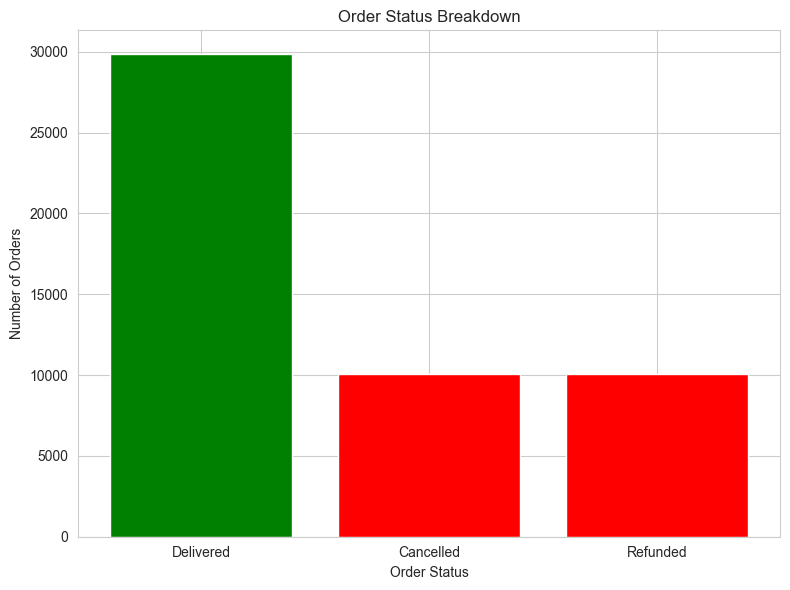

In [3]:
status_counts = df['OrderStatus'].value_counts()

colors = []
for status in status_counts.index:
    if status == 'Delivered':
        colors.append('green')
    else:
        colors.append('red')

plt.figure(figsize=(8, 6))
plt.bar(status_counts.index, status_counts.values, color=colors)
plt.title('Order Status Breakdown')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('../Dashboard/chart1_order_status.png')
plt.show()

**Finding:** Nearly 40% of all orders fail to complete — 20.19% Cancelled and 
20.14% Refunded, with only 59.67% successfully Delivered. This is the most 
critical operational issue in the dataset.

### Chart 2: Revenue by Acquisition Channel

Shows that all channels perform similarly — no clear winner.

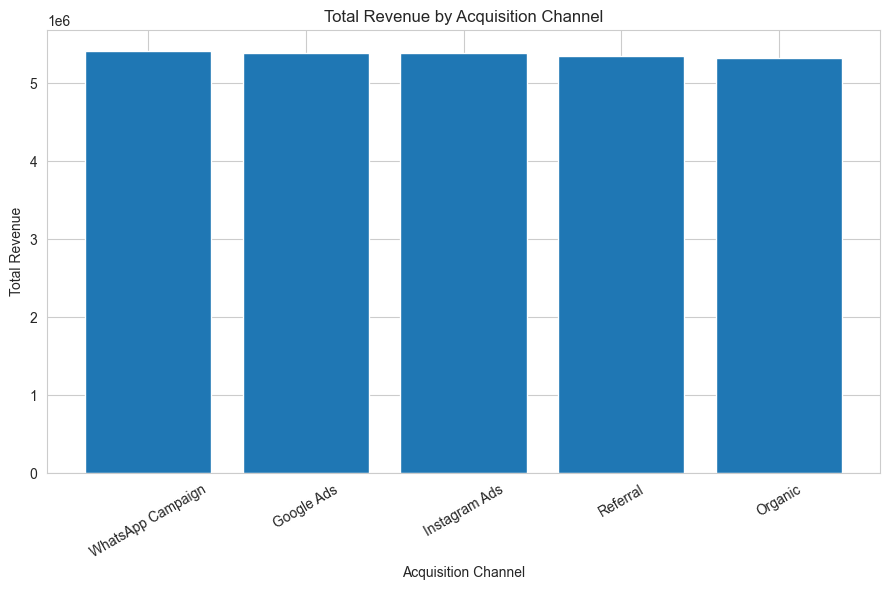

In [4]:
delivered = df[df['OrderStatus'] == 'Delivered']

channel_revenue = delivered.groupby('AcquisitionChannel')['OrderAmount'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 6))
plt.bar(channel_revenue.index, channel_revenue.values)
plt.title('Total Revenue by Acquisition Channel')
plt.xlabel('Acquisition Channel')
plt.ylabel('Total Revenue')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../dashboard/chart2_channel_revenue.png')
plt.show()

**Finding:** All 5 acquisition channels generate similar revenue (₹53-54L 
range), with no clear best-performing channel. Marketing spend allocation 
should be based on cost-per-acquisition rather than assumed revenue 
differences between channels.

### Chart 3: Revenue by Cuisine

North Indian leads, but the gap between cuisines is modest.

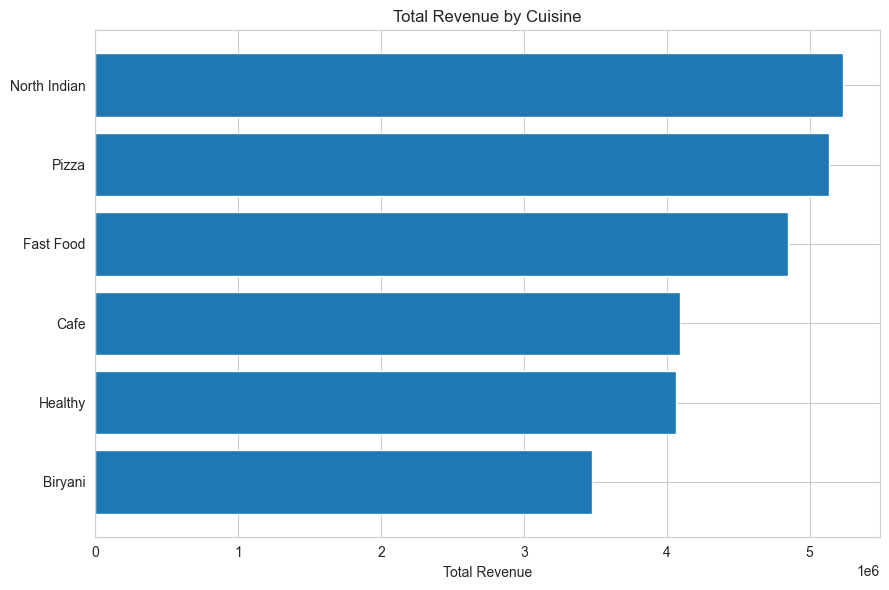

In [5]:
cuisine_revenue = delivered.groupby('Cuisine')['OrderAmount'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(cuisine_revenue.index[::-1], cuisine_revenue.values[::-1])
plt.title('Total Revenue by Cuisine')
plt.xlabel('Total Revenue')
plt.tight_layout()
plt.savefig('../dashboard/chart3_cuisine_revenue.png')
plt.show()

**Finding:** North Indian is the top-revenue cuisine, followed closely by 
Pizza and Fast Food. Revenue differences across cuisines are modest, and 
ratings don't strongly correlate with revenue.

### Chart 4: Cancellation Rate by City

Shows Chennai has the highest cancellation rate, Mumbai the lowest.

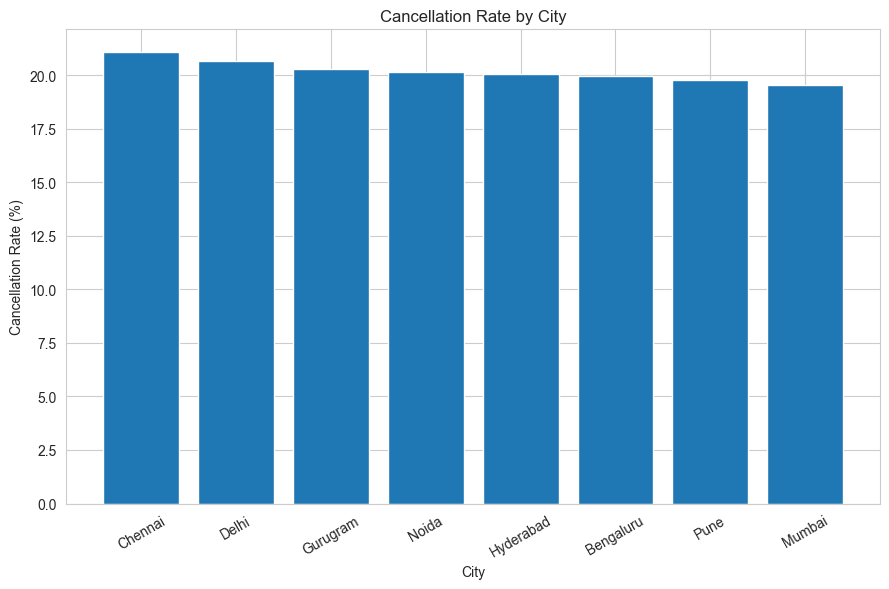

In [6]:
city_cancel = df.groupby('CustomerCity').agg(
    TotalOrders=('OrderID', 'count'),
    CancelledOrders=('IsCancelled', 'sum')
)
city_cancel['CancellationRate'] = city_cancel['CancelledOrders'] / city_cancel['TotalOrders'] * 100
city_cancel = city_cancel.sort_values('CancellationRate', ascending=False)

plt.figure(figsize=(9, 6))
plt.bar(city_cancel.index, city_cancel['CancellationRate'])
plt.title('Cancellation Rate by City')
plt.xlabel('City')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../dashboard/chart4_city_cancellation.png')
plt.show()

**Finding:** Chennai has the highest cancellation rate (~21%) while Mumbai 
has the lowest (~19.6%) — a modest but real gap worth investigating for 
city-specific delivery or restaurant capacity issues.

### Chart 5: Monthly Revenue Trend

Shows how revenue moves over time across the dataset's date range.

C:\Users\Mohit shrivastav\AppData\Local\Temp\ipykernel_20496\2649045047.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered['YearMonth'] = delivered['OrderTimestamp'].dt.to_period('M').astype(str)


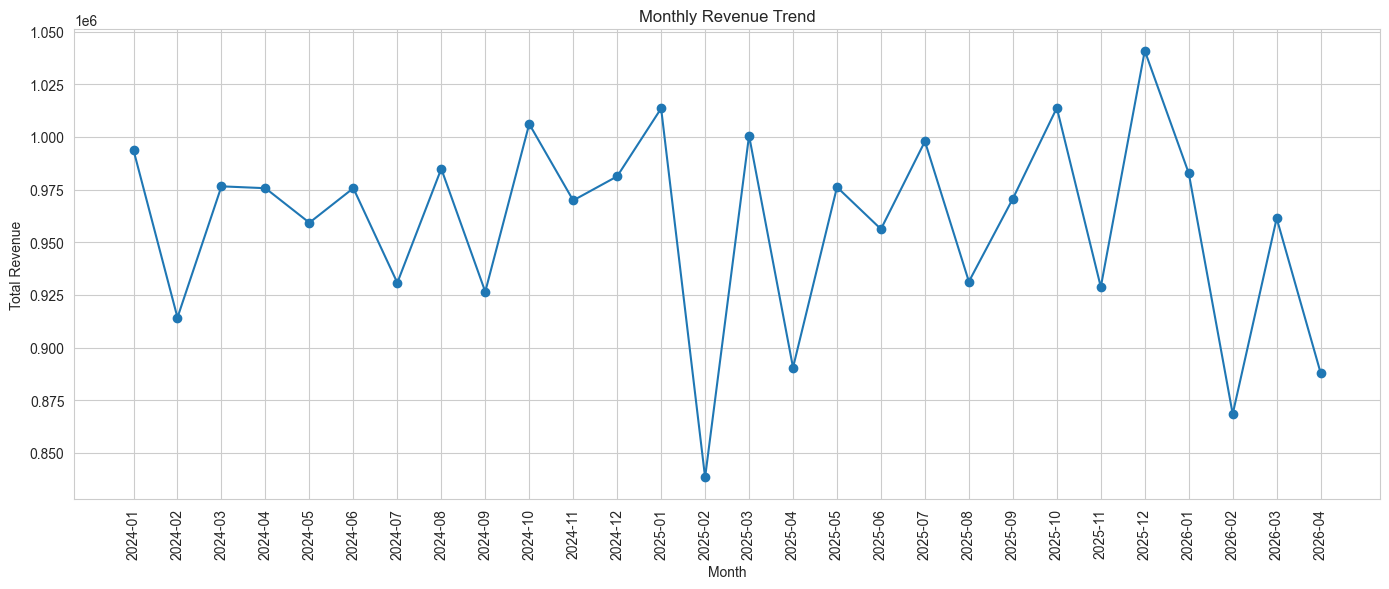

In [7]:
delivered['YearMonth'] = delivered['OrderTimestamp'].dt.to_period('M').astype(str)

monthly_revenue = delivered.groupby('YearMonth')['OrderAmount'].sum()

plt.figure(figsize=(14, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../dashboard/chart5_monthly_revenue.png')
plt.show()

**Finding:** Monthly revenue fluctuates between roughly ₹840K and ₹1.04M 
with no clear long-term growth or decline trend. Unlike a retail dataset 
with obvious holiday seasonality, this data shows no consistent repeating 
pattern across months — revenue appears relatively stable overall, with 
some individual low months (e.g., February 2025, February 2026) that may be 
worth investigating further, though the ~2-year window is too short to 
confirm this as a true seasonal pattern rather than noise.

### Chart 6: Cancellation Rate by Payment Mode

Shows cancellation rate is nearly flat across all payment methods.

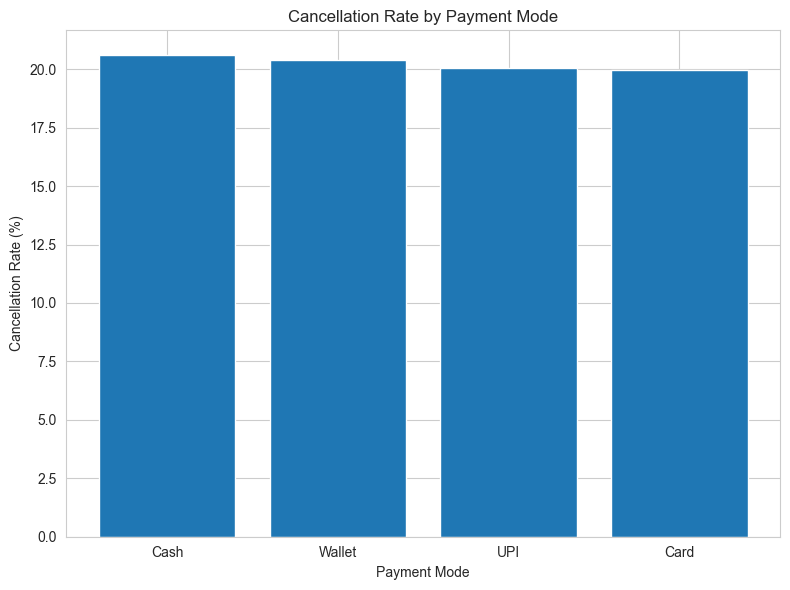

In [9]:
payment_cancel = df.groupby('PaymentMode').agg(
    TotalOrders=('OrderID', 'count'),
    CancelledOrders=('IsCancelled', 'sum')
)
payment_cancel['CancellationRate'] = payment_cancel['CancelledOrders'] / payment_cancel['TotalOrders'] * 100
payment_cancel = payment_cancel.sort_values('CancellationRate', ascending=False)

plt.figure(figsize=(8, 6))
plt.bar(payment_cancel.index, payment_cancel['CancellationRate'])
plt.title('Cancellation Rate by Payment Mode')
plt.xlabel('Payment Mode')
plt.ylabel('Cancellation Rate (%)')
plt.tight_layout()
plt.savefig('../dashboard/chart6_payment_cancellation.png')
plt.show()

**Finding:** Cancellation rate is nearly identical across all payment modes 
(19.96%-20.63%), reinforcing that the ~40% order failure rate is a systemic 
issue rather than tied to a specific payment method.

## Summary

This notebook validated the SQL analysis findings using Python and produced 
6 visualizations covering order status, acquisition channel revenue, cuisine 
performance, city-level cancellation rates, monthly revenue trends, and 
payment mode cancellation consistency. Additional Python-only analysis 
revealed that cancellation rate is consistent across payment modes and 
cuisines, pointing to a systemic rather than segment-specific cause behind 
the high order failure rate.

**Next step:** Build an interactive Power BI dashboard connected to the SQL 
Server database.